In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pickle
import pyvisa
import time 
import os 
from datetime import datetime  
import nysg_tools as ny
import os
import pickle
import glob as glob
from scipy.optimize import curve_fit


In [2]:
from cmath import sqrt

file_list = sorted(glob.glob("09h_50m_25s/*.pkl"))

frequencies = []
r_values = []
phases = []
x_mean = []
y_mean =[]

x_std = []
y_std = []
for file in file_list:
    with open(file, "rb") as f:
        data = pickle.load(f)
        # print(data)
        frequencies.append(data['frequency_Hz'])
        r_values.append(np.abs(data['R_V_mean'] / (2* sqrt(2)) ))
        phases.append(data['Theta_deg_mean']) 

        x_mean.append(np.real(data['X_V_mean']* 2* sqrt(2))) 
        y_mean.append(np.real(data['Y_V_mean']* 2* sqrt(2)) )

        x_std.append(data['X_V_std']) 
        y_std.append(data['Y_V_std'] )
        # etc...

f = np.array(frequencies)
r = np.array(r_values)
theta = np.array(phases)
x = np.array(x_mean)
y = np.array(y_mean)
x_s = np.array(x_std)
y_s = np.array(y_std)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ---------------------------------------------------------
# 1. LOAD DATA & SET CONSTANTS
# ---------------------------------------------------------
freq = f
V_meas = r

# The exact circuit parameters
V_source = 0.5 / np.sqrt(2)  # 1Vpp to Vrms
Rs = 10000.0                 # The known 10k Ohm sense resistor

# The observed resonance frequencies
fs = 50096.3
fp = 50284.5

# Analytical constraint: C1/C0 ratio derived from fs and fp
C1_C0_ratio = (fp / fs)**2 - 1 

# ---------------------------------------------------------
# 2. THE THEORETICAL MODEL
# ---------------------------------------------------------
def BVD_voltage_divider(f, R1, C0):
    C1 = C1_C0_ratio * C0
    ws = 2 * np.pi * fs
    L1 = 1.0 / (ws**2 * C1)
    
    w = 2 * np.pi * f
    Z_m = R1 + 1j * (w * L1 - 1.0 / (w * C1))
    Z_C0 = 1.0 / (1j * w * C0)
    Z_xtal = (Z_m * Z_C0) / (Z_m + Z_C0)
    
    V_pred = V_source * Rs / np.abs(Rs + Z_xtal)
    return V_pred

def objective_function(params):
    R1 = np.exp(params[0])  
    C0 = np.exp(params[1])
    V_pred = BVD_voltage_divider(freq, R1, C0)
    residuals = np.log(V_pred + 1e-10) - np.log(V_meas + 1e-10)
    return np.sum(residuals**2)

# ---------------------------------------------------------
# 3. OPTIMIZATION
# ---------------------------------------------------------
x0 = [np.log(35000), np.log(1e-12)]

print("Optimizing parameters (R1, C0)...")
res = minimize(
    objective_function, 
    x0, 
    method='Nelder-Mead', 
    options={'maxiter': 50000, 'xatol': 1e-10, 'fatol': 1e-12}
)

R1_final = np.exp(res.x[0])
C0_final = np.exp(res.x[1])
C1_final = C1_C0_ratio * C0_final
L1_final = 1.0 / ((2 * np.pi * fs)**2 * C1_final)
Q_final = (2 * np.pi * fs * L1_final) / R1_final

V_fit = BVD_voltage_divider(freq, R1_final, C0_final)


Optimizing parameters (R1, C0)...


In [4]:
Q_final

np.float64(16054.77486324119)

In [5]:
popt = [R1_final, L1_final,C0_final, C1_final]

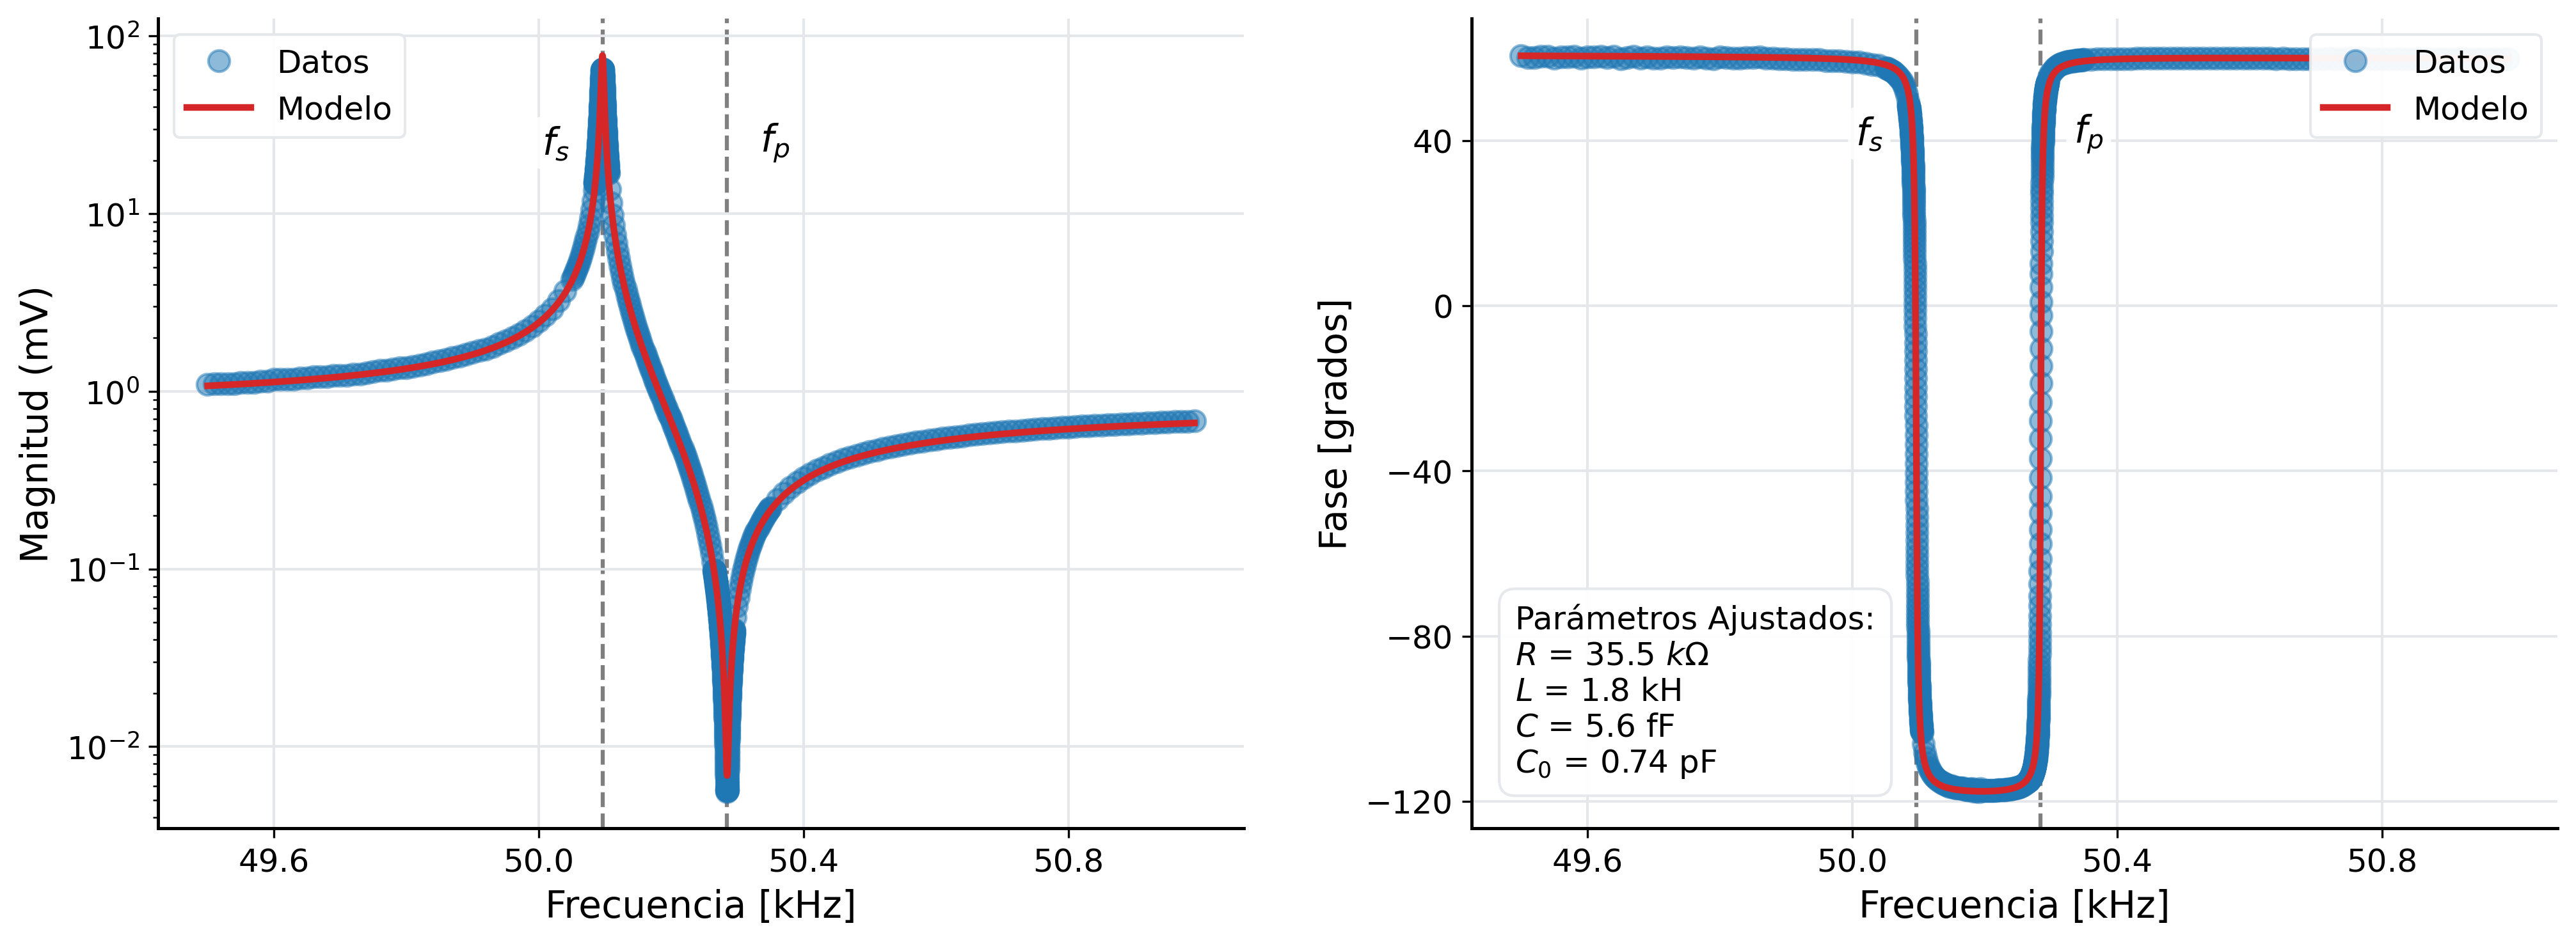

In [6]:

# The updated model with the 300 pF parasitic capacitance
def transfer_function_with_parasitic(f, R, L, C, C2):
    R2 = 10000
    Cp = 180e-12  # Fixed to 300 pF as intended

    w = 2 * np.pi * f 

    # Piezoelectric impedance
    Zm = R + 1j * (w * L - 1 / (w * C))
    Z_pzt = 1 / (1 / Zm + 1j * w * C2)

    # Measurement impedance (R2 in parallel with Cp)
    Z_meas = 1 / (1 / R2 + 1j * w * Cp) 
    
    # Transfer function
    H = Z_meas / (Z_pzt + Z_meas) 

    return H

# Unpack your fitted parameters
# popt contains: [R1_final, L1_final, C0_final, C1_final]
R_fit, L_fit, C2_fit, C_fit = popt

# Calculate the complex transfer function
H_complex = transfer_function_with_parasitic(f, R_fit, L_fit, C_fit, C2_fit)

# Convert to predicted Voltage (magnitude) and Phase (degrees)
V_source = 0.5 / np.sqrt(2) 
V_pred_mag = np.abs(H_complex) * V_source
V_pred_phase = np.angle(H_complex, deg=True)

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


# Convert frequencies to kHz for cleaner axis labels
f_kHz = f / 1000
fs_kHz = fs / 1000
fp_kHz = fp / 1000

# Update global parameters for poster readability
plt.rcParams.update({
    'font.size': 14,          
    'axes.titlesize': 16,     
    'axes.labelsize': 14,     
    'xtick.labelsize': 12,    
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'lines.linewidth': 2.5    
})

# High DPI for crisp printing
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), dpi=300)
fig.patch.set_facecolor('white')

COLOR_DATA = '#1f77b4'  # Deep blue for data
COLOR_FIT = '#d62728'   # Crimson red for fit
COLOR_LINES = '#7f7f7f' # Gray for highlights

# Box style for text labels to ensure readability over lines
text_box_style = dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.85)

for ax in axes:
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.grid(True, which="major", color='#e5e7eb', ls="-", lw=1)

ax1 = axes[0]
ax1.plot(f_kHz, r * 1000, 'o', color=COLOR_DATA, markersize=8, label='Datos', alpha=0.5)
ax1.plot(f_kHz, V_fit * 1000, '-', color=COLOR_FIT, lw=2.5, label='Modelo')

ax1.set_yscale('log')
ax1.set_xlabel('Frecuencia [kHz]')
ax1.set_ylabel('Magnitud (mV)')
# ax1.set_title('Magnitude Response')

# Highlight fs and fp
ax1.axvline(fs_kHz, color=COLOR_LINES, ls='--', lw=1.5, zorder=0)
ax1.axvline(fp_kHz, color=COLOR_LINES, ls='--', lw=1.5, zorder=0)

# Add highly visible text labels for the frequencies
y_min, y_max = ax1.get_ylim()
ax1.text(fs_kHz - 0.05, y_max * 0.2, '$f_s$', color='black', fontsize=14, ha='right', va='center', bbox=text_box_style)
ax1.text(fp_kHz + 0.05, y_max * 0.2, '$f_p$', color='black', fontsize=14, ha='left', va='center', bbox=text_box_style)

# Reduce axis tick clutter
ax1.xaxis.set_major_locator(MaxNLocator(nbins=5))

# Move legend out of the way and give it a background
ax1.legend(frameon=True, loc='upper left', edgecolor='#e5e7eb', facecolor='white', framealpha=0.95)

# --- Right: Phase ---
ax2 = axes[1]
ax2.plot(f_kHz, theta, 'o', color=COLOR_DATA, markersize=8, label='Datos', alpha=0.5)
ax2.plot(f_kHz, V_pred_phase, '-', color=COLOR_FIT, lw=2.5, label='Modelo')

ax2.set_xlabel('Frecuencia [kHz]')
ax2.set_ylabel('Fase [grados]')
# ax2.set_title('Phase Response')

# Highlight fs and fp
ax2.axvline(fs_kHz, color=COLOR_LINES, ls='--', lw=1.5, zorder=0)
ax2.axvline(fp_kHz, color=COLOR_LINES, ls='--', lw=1.5, zorder=0)

y_min2, y_max2 = ax2.get_ylim()
ax2.text(fs_kHz - 0.05, y_max2 * 0.6, '$f_s$', color='black', fontsize=14, ha='right', va='center', bbox=text_box_style)
ax2.text(fp_kHz + 0.05, y_max2 * 0.6, '$f_p$', color='black', fontsize=14, ha='left', va='center', bbox=text_box_style)

# Reduce axis tick clutter
ax2.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax2.yaxis.set_major_locator(MaxNLocator(nbins=5))

# Move legend out of the way
ax2.legend(frameon=True, loc='upper right', edgecolor='#e5e7eb', facecolor='white', framealpha=0.95)

param_text = (
    f"Parámetros Ajustados:\n"
    f"$R$ = 35.5 $k\\Omega$\n"
    f"$L$ = 1.8 kH\n"
    f"$C$ = 5.6 fF\n"
    f"$C_0$ = 0.74 pF"
)
ax2.text(0.04, 0.06, param_text, transform=ax2.transAxes,
         fontsize=12, va='bottom', ha='left', color='black',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#e5e7eb', alpha=0.95))

plt.tight_layout(pad=2)
plt.show()

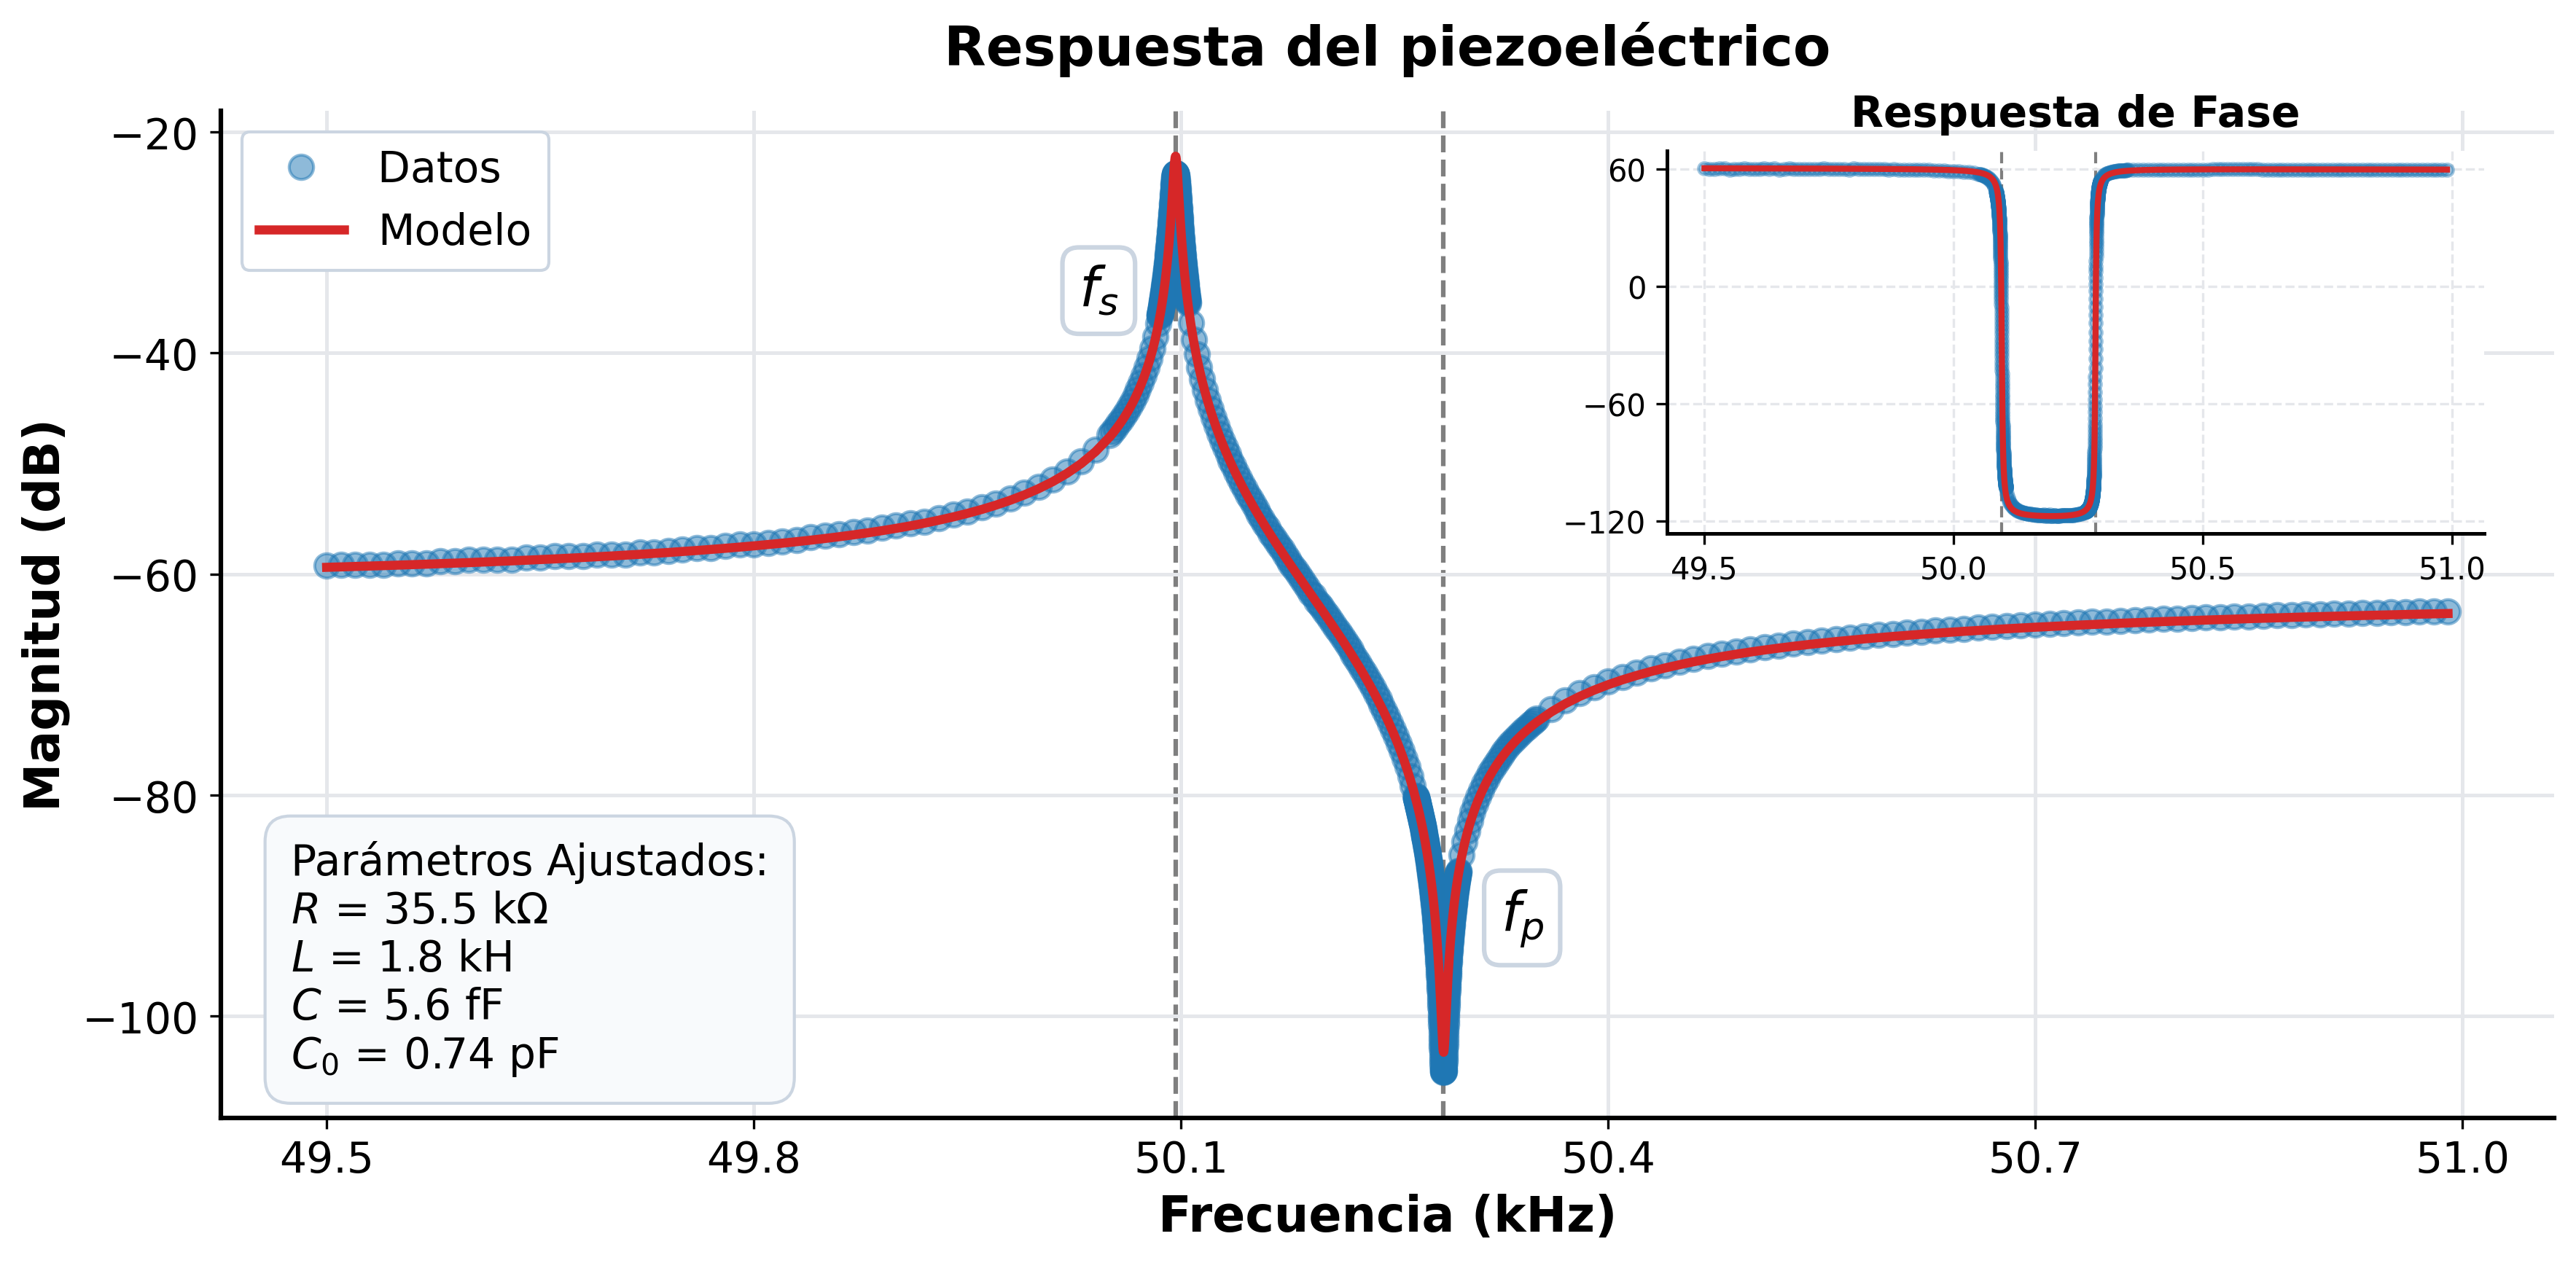

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# Convertir frecuencias a kHz
f_kHz = f / 1000
fs_kHz = fs / 1000
fp_kHz = fp / 1000

# Convertir magnitudes absolutas a Decibeles (dB)
r_dB = 20 * np.log10(r)
V_pred_dB = 20 * np.log10(V_fit)

# Actualizar parámetros globales para legibilidad en póster
plt.rcParams.update({
    'font.size': 14,          
    'axes.titlesize': 18,     
    'axes.labelsize': 16,     
    'xtick.labelsize': 14,    
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'lines.linewidth': 2.5    
})

# Crear la figura principal
fig, ax1 = plt.subplots(figsize=(12,6), dpi=300)
fig.patch.set_facecolor('white')

COLOR_DATA = '#1f77b4'  # Azul oscuro
COLOR_FIT = '#d62728'   # Rojo carmesí
COLOR_LINES = '#7f7f7f' # Gris

# Cajas de texto opacas para resaltar fs y fp
text_box_style = dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#cbd5e1", linewidth=1.5, alpha=1.0)

# --- Gráfico Principal: Magnitud (en dB) ---
ax1.set_facecolor('white')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(1.5)
ax1.spines['bottom'].set_linewidth(1.5)
ax1.grid(True, which="major", color='#e5e7eb', ls="-", lw=1.2)

ax1.plot(f_kHz, r_dB, 'o', color=COLOR_DATA, markersize=8, label='Datos ', alpha=0.5)
ax1.plot(f_kHz, V_pred_dB, '-', color=COLOR_FIT, lw=3, label='Modelo')

ax1.set_xlabel('Frecuencia (kHz)', fontweight='bold')
ax1.set_ylabel('Magnitud (dB)', fontweight='bold')
ax1.set_title('Respuesta del piezoeléctrico', fontweight='bold', pad=15)

# Resaltar fs y fp
ax1.axvline(fs_kHz, color=COLOR_LINES, ls='--', lw=1.5, zorder=0)
ax1.axvline(fp_kHz, color=COLOR_LINES, ls='--', lw=1.5, zorder=0)

# Ubicar fs y fp dinámicamente según la escala de dB
v_max = np.max(V_pred_dB)
v_min = np.min(V_pred_dB)
v_span = v_max - v_min

ax1.text(fs_kHz - 0.04, v_max - 0.15 * v_span, '$f_s$', color='black', fontsize=18, fontweight='bold', ha='right', va='center', bbox=text_box_style, zorder=5)
ax1.text(fp_kHz + 0.04, v_min + 0.15 * v_span, '$f_p$', color='black', fontsize=18, fontweight='bold', ha='left', va='center', bbox=text_box_style, zorder=5)

# Limpiar los ticks
ax1.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax1.legend(frameon=True, loc='upper left', edgecolor='#cbd5e1', facecolor='white', framealpha=1.0)

# --- Caja de Parámetros (Abajo a la izquierda) ---
param_text = (
    f"Parámetros Ajustados:\n"
    f"$R$ = 35.5 k$\\Omega$\n"
    f"$L$ = 1.8 kH\n"
    f"$C$ = 5.6 fF\n"
    f"$C_0$ = 0.74 pF"
)

ax1.text(0.03, 0.04, param_text, transform=ax1.transAxes,
         fontsize=14, va='bottom', ha='left', color='black', zorder=5,
         bbox=dict(boxstyle='round,pad=0.6', facecolor='#f8fafc', edgecolor='#cbd5e1', alpha=1.0))

# --- Gráfico Inset: Fase (Arriba a la derecha) ---
ax_inset = ax1.inset_axes([0.62, 0.58, 0.35, 0.38])
ax_inset.set_facecolor('white')

ax_inset.plot(f_kHz, theta, 'o', color=COLOR_DATA, markersize=4, alpha=0.4)
ax_inset.plot(f_kHz, V_pred_phase, '-', color=COLOR_FIT, lw=2)

# Título sin etiqueta en el eje Y
ax_inset.set_title('Respuesta de Fase', fontsize=14, pad=8, fontweight='bold')

# Dejar explícitamente solo el 50 y el -130 en el eje Y
ax_inset.set_yticks([60, 0,-60, -120])

ax_inset.axvline(fs_kHz, color=COLOR_LINES, ls='--', lw=1, zorder=0)
ax_inset.axvline(fp_kHz, color=COLOR_LINES, ls='--', lw=1, zorder=0)

# Estética del inset
ax_inset.spines['top'].set_visible(False)
ax_inset.spines['right'].set_visible(False)
ax_inset.spines['left'].set_linewidth(1.2)
ax_inset.spines['bottom'].set_linewidth(1.2)
ax_inset.xaxis.set_major_locator(MaxNLocator(nbins=4))
ax_inset.tick_params(labelsize=10)
ax_inset.grid(True, color='#e5e7eb', ls="--", lw=0.8)

plt.tight_layout()
plt.show()